# 01 — Exploratory QA

Histograms / ECDFs, degree vs curvature / radius, 3D positions, and hub labels from ``cache/merged.parquet`` (re-run ``00`` if missing).

**Load cached merge**

Reads `cache/merged.parquet` produced by notebook `00`. If the file is missing, run `00_load_and_sanity.ipynb` first (or change `RUN_SUBDIR` there and regenerate).

In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 200  # default 100; sharper inline figures
import numpy as np
import pandas as pd
from scipy import stats

import dmercator_io as dm

cache = Path("cache") / "merged.parquet"
if not cache.is_file():
    raise FileNotFoundError(f"Run 00 first: missing {cache}")

merged = dm.load_merged_parquet(cache)
merged.head()


,Vertex,Inf.Kappa,Inf.Hyp.Rad,Inf.Pos.1,Inf.Pos.2,Inf.Pos.3,degree
0,AR,731.5360,12.2905,10.96580,-22.6755,-26.9361,258
1,C2,13.6037,16.2753,7.44475,24.2101,26.8035,12
2,C3,170.4760,13.7471,-9.22702,-26.8317,23.5563,62
3,C5,61.4501,14.7674,14.42630,24.0795,23.9173,25
4,C6,12.6061,16.3515,-7.28107,-14.5304,33.1033,5


**Univariate distributions**

Histograms for log-scaled κ, hyperbolic radius, degree, and log-degree. **Interpretation:** use these to verify the run finished sensibly (no all-zero columns, no single spike dominating everything).

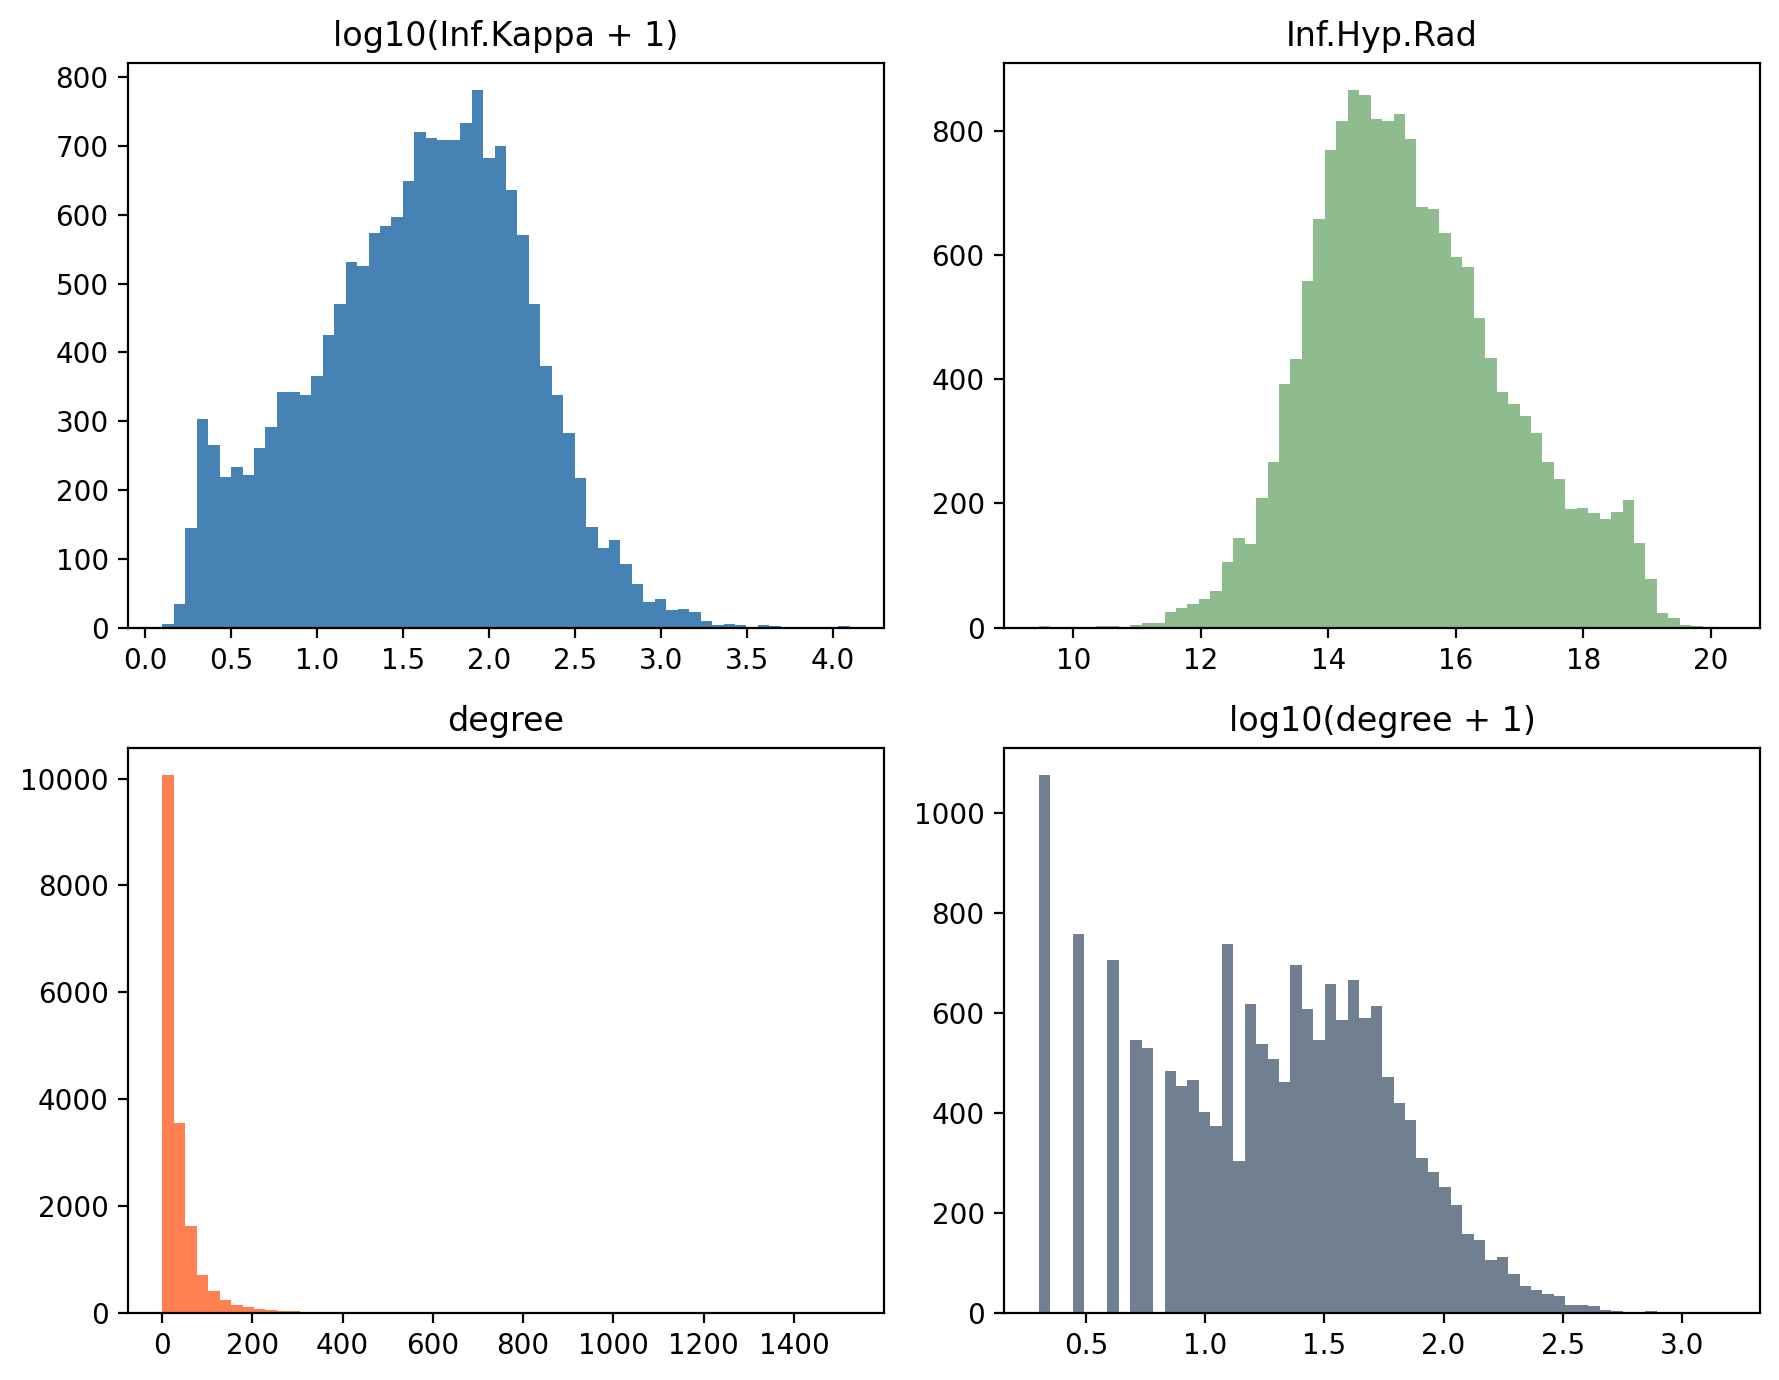

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
axes[0, 0].hist(np.log10(merged["Inf.Kappa"] + 1), bins=60, color="steelblue", edgecolor="none")
axes[0, 0].set_title("log10(Inf.Kappa + 1)")
axes[0, 1].hist(merged["Inf.Hyp.Rad"], bins=60, color="darkseagreen", edgecolor="none")
axes[0, 1].set_title("Inf.Hyp.Rad")
axes[1, 0].hist(merged["degree"], bins=60, color="coral", edgecolor="none")
axes[1, 0].set_title("degree")
axes[1, 1].hist(np.log10(merged["degree"] + 1), bins=60, color="slategray", edgecolor="none")
axes[1, 1].set_title("log10(degree + 1)")
plt.tight_layout()
plt.show()


**Interpreting the univariate histograms**

1. **`log10(Inf.Kappa + 1)`** — κ from Mercator is usually heavy-tailed; the log view shows where most vertices sit. Extra bumps can hint at subgroups (e.g. hubs vs typical proteins sitting at different κ).

2. **`Inf.Hyp.Rad`** — Hyperbolic radius is on a tighter scale than degree. A roughly bell-shaped bulk is common; slight shoulders may mark subpopulations with different radial placement in the inferred geometry.

3. **`degree` (raw)** — PPI graphs are almost always **strongly right-skewed**: a tall spike at low degrees and a thin tail of hubs. That reflects the graph you passed in, not necessarily an embedding bug.

4. **`log10(degree + 1)`** — Same counts on a log axis: discrete spikes at the left correspond to small integer degrees (1, 2, 3, …); the broader middle shows how typical proteins spread once the low-degree pile-up is readable.

**Together** — Use the Spearman / correlation cells below for **joint** structure (how degree lines up with κ and radius). These four panels are mainly **sanity checks** (no all-zero κ, no collapsed degree) rather than a full model diagnosis by themselves.


**Empirical CDFs**

Plots empirical CDFs of κ and degree on linear x-axes. **Interpretation:** long upper tails are typical; compare curves qualitatively rather than expecting Gaussian shapes.

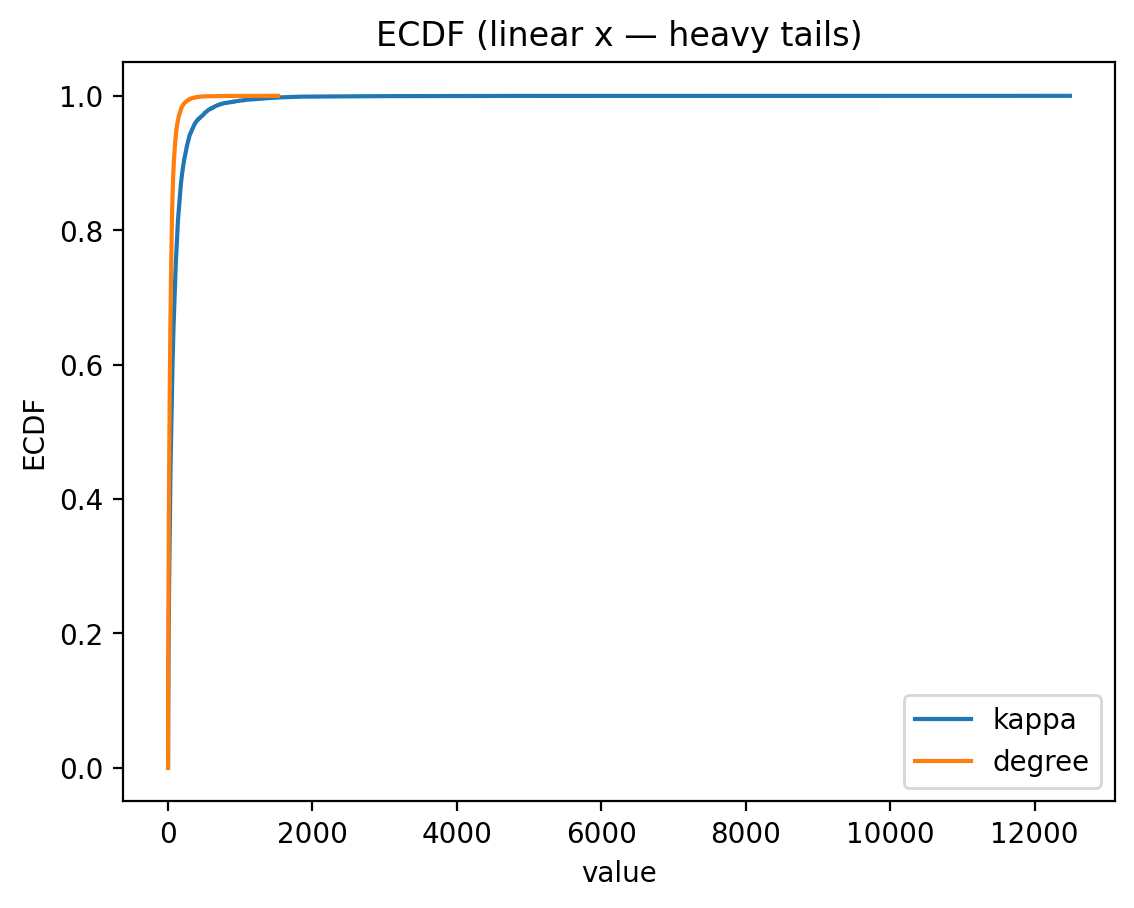

In [20]:
# ECDFs for kappa and degree
for col, label in [("Inf.Kappa", "kappa"), ("degree", "degree")]:
    x = np.sort(merged[col].to_numpy())
    y = np.linspace(0, 1, len(x), endpoint=False)
    plt.plot(x, y, label=label)
plt.xlabel("value")
plt.ylabel("ECDF")
plt.legend()
plt.title("ECDF (linear x — heavy tails)")
plt.show()


**Spearman rank correlations**

Nonparametric association between degree and `Inf.Kappa` / `Inf.Hyp.Rad`. **Interpretation:** strong `rho` suggests hubs sit in systematically different curvature or radius bands; very small `p` is common with thousands of vertices (do not treat as “effect size”).

In [21]:
rho, p = stats.spearmanr(merged["degree"], merged["Inf.Kappa"])
print(f"Spearman degree vs Inf.Kappa: rho={rho:.4f} p={p:.2e}")
rho2, p2 = stats.spearmanr(merged["degree"], merged["Inf.Hyp.Rad"])
print(f"Spearman degree vs Inf.Hyp.Rad: rho={rho2:.4f} p={p2:.2e}")


Spearman degree vs Inf.Kappa: rho=0.9731 p=0.00e+00
Spearman degree vs Inf.Hyp.Rad: rho=-0.9731 p=0.00e+00


In [ ]:
# Joint plot: degree vs inferred hyperbolic radius
# Hexbin shows density where points overlap; log1p(degree) spreads the low-degree pile-up.
# A faint subsampled scatter helps see the high-degree tail. Expect Spearman ρ < 0 (hubs → smaller radius).

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

deg = merged["degree"].to_numpy(dtype=float)
rad = merged["Inf.Hyp.Rad"].to_numpy(dtype=float)
lx = np.log1p(deg)
rho, _ = stats.spearmanr(deg, rad)

fig, ax = plt.subplots(figsize=(8, 6))
hb = ax.hexbin(
    lx,
    rad,
    gridsize=(72, 48),
    mincnt=1,
    cmap="YlOrRd",
    linewidths=0,
    bins="log",
)
cb = fig.colorbar(hb, ax=ax)
cb.set_label("count (log scale)")

rng = np.random.default_rng(0)
n = len(merged)
cap = min(12_000, n)
idx = rng.choice(n, size=cap, replace=False)
ax.scatter(lx[idx], rad[idx], s=3, c="0.15", alpha=0.06, linewidths=0, rasterized=True, zorder=2)

ax.set_xlabel("log1p(degree)")
ax.set_ylabel("Inf.Hyp.Rad")
ax.set_title("Degree vs hyperbolic radius")
ax.text(
    0.02,
    0.98,
    f"Spearman ρ = {rho:.3f}",
    transform=ax.transAxes,
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.85, edgecolor="0.7"),
)
fig.tight_layout()
plt.show()


**3D scatter (subsample)**

Three **3D** panels show the same subsample from different `view_init` angles; one **shared colorbar** maps `log1p(degree)` to color across all panels. **Interpretation:** this is *not* the Poincaré disk—it's the ambient coordinates Mercator inferred. Color highlights whether high-degree nodes occupy particular regions of that space.


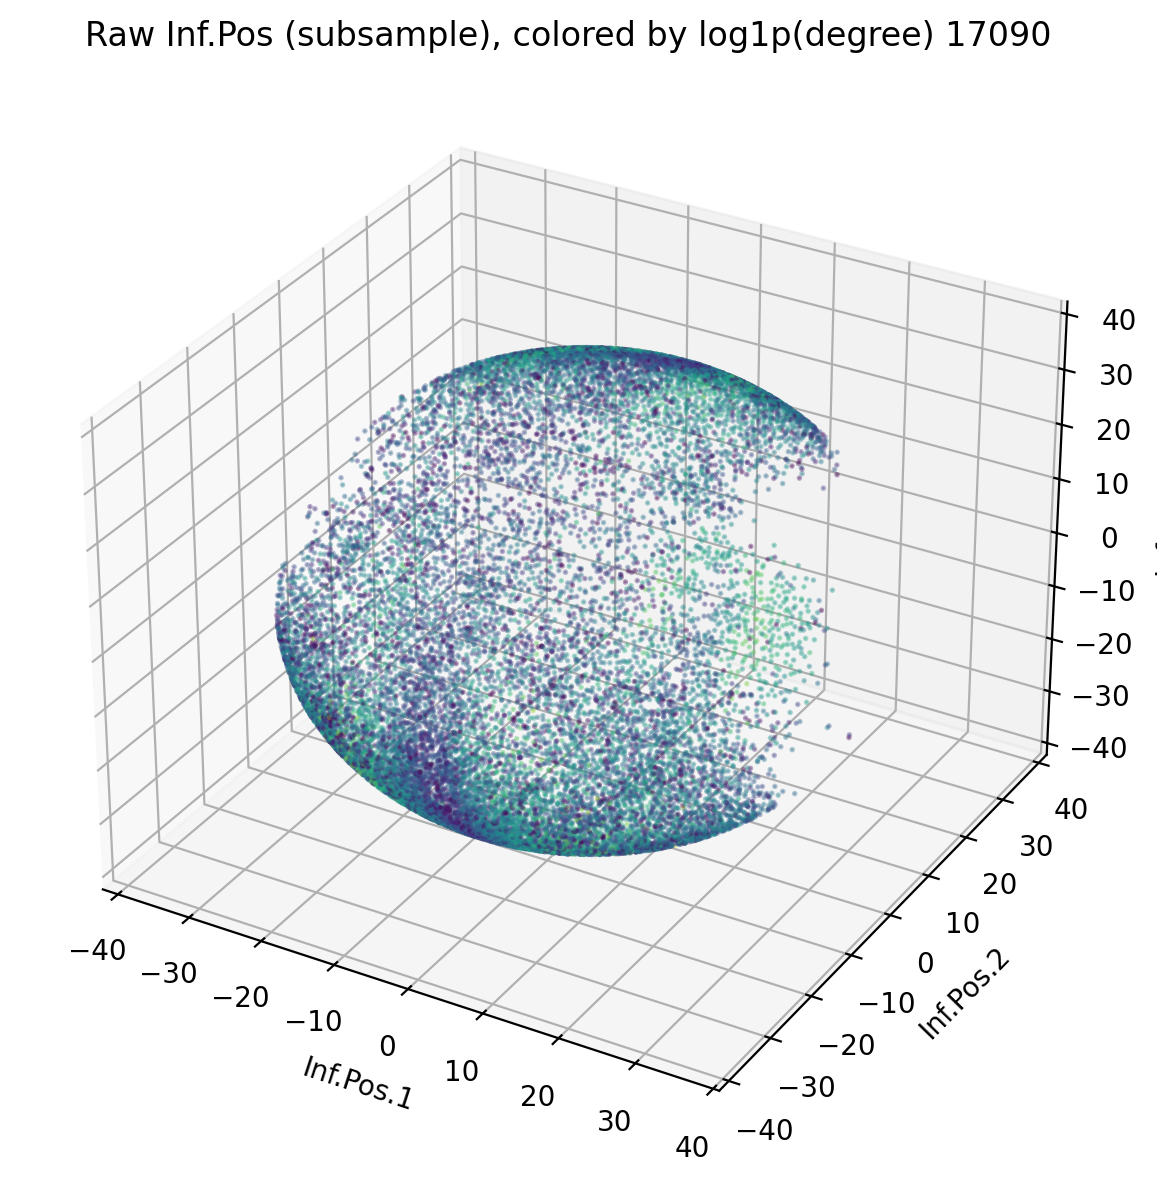

In [31]:
# 3D scatter (subsample for speed) — three viewpoints, same color scale
rng = np.random.default_rng(0)
n = min(800000, len(merged))
ix = rng.choice(len(merged), size=n, replace=False)
sub = merged.iloc[ix]
deg_c = np.log1p(sub["degree"].to_numpy())
vmin, vmax = float(deg_c.min()), float(deg_c.max())

fig = plt.figure(figsize=(22, 7))
axes3d = []
views = [
    (22, -45, "view 1: elev 22°, azim -45°"),
    (10, 60, "view 2: elev 10°, azim 60°"),
    (55, 120, "view 3: elev 55°, azim 120°"),
]
for k, (elev, azim, vtitle) in enumerate(views):
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    sc = ax.scatter(
        sub["Inf.Pos.1"],
        sub["Inf.Pos.2"],
        sub["Inf.Pos.3"],
        c=deg_c,
        s=1,
        alpha=0.35,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel("Inf.Pos.1")
    ax.set_ylabel("Inf.Pos.2")
    ax.set_zlabel("Inf.Pos.3")
    ax.set_title(vtitle)
    axes3d.append(ax)

fig.colorbar(sc, ax=axes3d, shrink=0.55, pad=0.06, label="log1p(degree)")
plt.suptitle("Raw Inf.Pos (subsample n=%d), colored by log1p(degree)" % n, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


**Pairwise scatter of raw positions**

Three 2D projections of `Inf.Pos.*` in **one column** (stacked panels). Points are colored by **`log1p(degree)`** (viridis) with the **same vmin/vmax** on every panel plus a **colorbar per panel** so hue is comparable. Use this to spot outliers or dense shells; heavy overlap is still normal in high-dimensional embeddings.


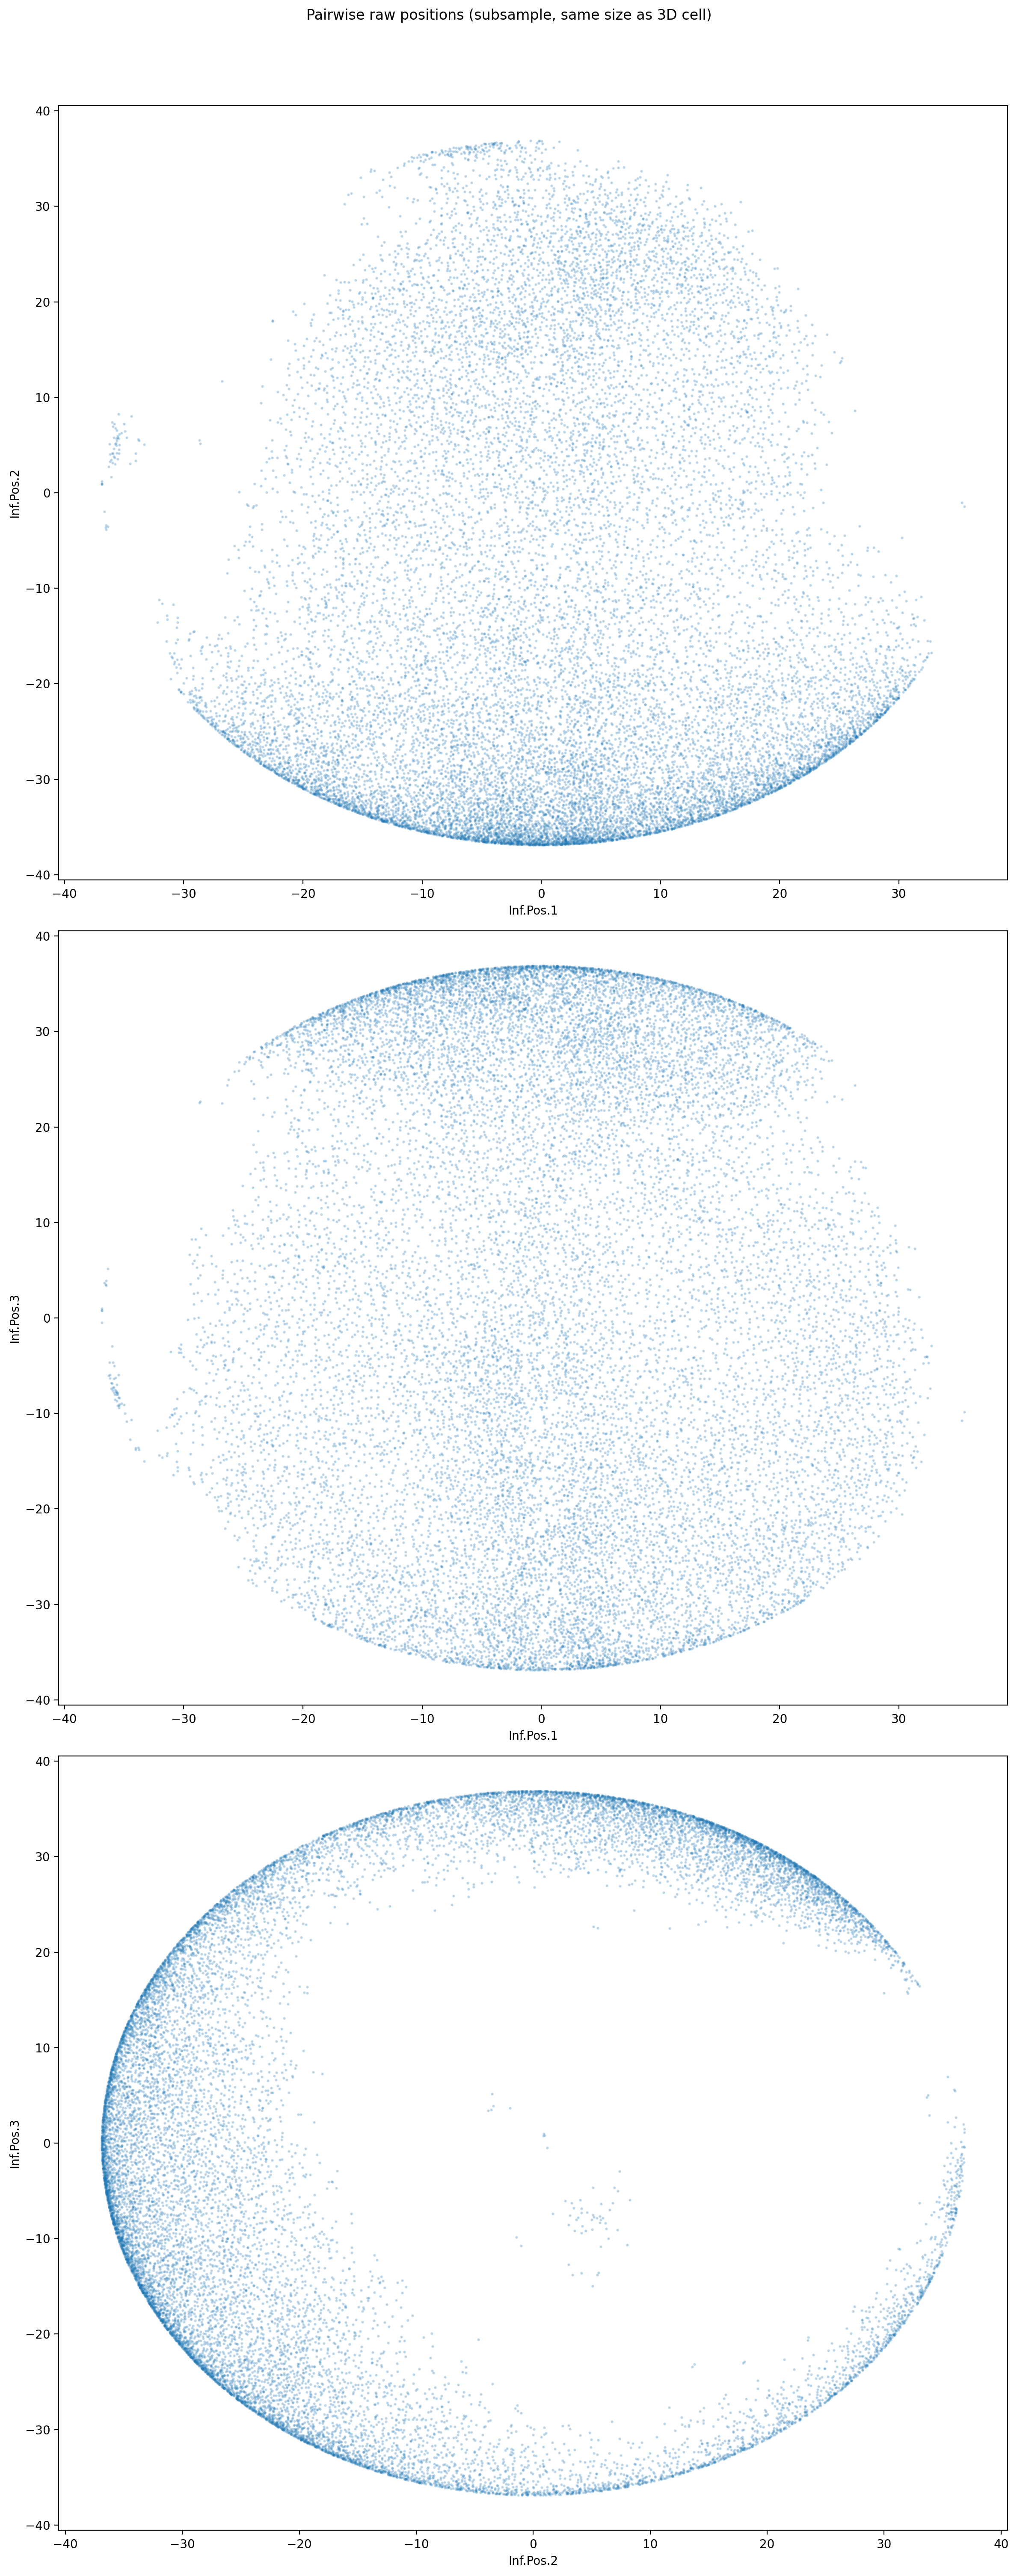

In [33]:
# 2D pairs (raw positions) — colored by log1p(degree), shared color scale
rng2 = np.random.default_rng(0)
n2 = min(80000, len(merged))
ix2 = rng2.choice(len(merged), size=n2, replace=False)
sub2 = merged.iloc[ix2]
cols = ["Inf.Pos.1", "Inf.Pos.2", "Inf.Pos.3"]
cdeg = np.log1p(sub2["degree"].to_numpy())
vmin, vmax = float(cdeg.min()), float(cdeg.max())

fig, axes = plt.subplots(3, 1, figsize=(12, 30))
pairs = [(0, 1), (0, 2), (1, 2)]
for ax, (i, j) in zip(axes, pairs):
    sc = ax.scatter(
        sub2[cols[i]],
        sub2[cols[j]],
        c=cdeg,
        s=2,
        alpha=0.35,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )
    plt.colorbar(sc, ax=ax, shrink=0.75, label="log1p(degree)")
    ax.set_xlabel(cols[i])
    ax.set_ylabel(cols[j])
plt.suptitle("Pairwise raw positions (subsample), colored by log1p(degree)", y=1.002)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


**High-degree proteins**

Lists the top vertices by degree with curvature and hyperbolic radius. **Interpretation:** hubs are often functionally central; compare `Inf.Kappa` and `Inf.Hyp.Rad` qualitatively but avoid over-reading without a generative model.

In [24]:
# Top hubs by degree
top = merged.nlargest(15, "degree")[["Vertex", "degree", "Inf.Kappa", "Inf.Hyp.Rad"]]
top


,Vertex,degree,Inf.Kappa,Inf.Hyp.Rad
3119,PRKN,1523,12486.70,9.45324
390,MYC,1266,11755.60,9.51358
283,HTT,832,3678.87,10.67530
1267,CUL3,779,4774.19,10.41470
3795,TP53,743,3796.42,10.64390
6274,HSPA8,734,3662.63,10.67970
9889,YWHAG,673,2924.84,10.90470
7067,MEOX2,667,2814.98,10.94300
707,ANLN,608,4463.82,10.48190
972,CCNF,572,3462.00,10.73610
